In [1]:
"""
Feature Detection Comparison - Main Experiment Notebook
Replication of Zhou (2024) - SIFT, SURF, SuperPoint, D2-Net Comparison

IMPORTANT: Execute cells sequentially from top to bottom
"""

import sys
from pathlib import Path

import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Add project to path
project_root = Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("✓ Environment setup complete")


✓ Environment setup complete


In [3]:
torch.set_default_dtype(torch.float32)
device = torch.device("cpu")
print("Device :", device)

Device : cpu


In [ ]:
"""
Download pretrained models for SuperPoint and D2-Net
Execute this cell only once
"""

import download_models

print("\nStarting model download...")
print("This may take a few minutes depending on your connection.\n")

success = download_models.download_pretrained_models()

if not success:
    print("\nWARNING: Some models failed to download.")
    print("You can still run SIFT and SURF experiments.")
    print("SuperPoint and D2-Net will be skipped.")

INFO:download_models:Downloading from https://github.com/magicleap/SuperPointPretrainedNetwork/raw/master/superpoint_v1.pth
INFO:download_models:Destination: pretrained_models/superpoint_v1.pth



Starting model download...
This may take a few minutes depending on your connection.

DOWNLOADING PRETRAINED MODELS FOR FEATURE DETECTION


SuperPoint:
  Description: SuperPoint pretrained on MS-COCO (MagicLeap)
--------------------------------------------------------------------------------
  Progress: 100.0%

INFO:download_models:✓ Successfully downloaded pretrained_models/superpoint_v1.pth (4.96 MB)
INFO:download_models:Downloading from https://dusmanu.com/files/d2-net/d2_tf.pth




D2-Net:
  Description: D2-Net pretrained on MegaDepth (CVPR 2019)
--------------------------------------------------------------------------------


INFO:download_models:Destination: pretrained_models/d2_tf.pth


  Progress: 100.0%

INFO:download_models:✓ Successfully downloaded pretrained_models/d2_tf.pth (29.13 MB)




DOWNLOAD SUMMARY
  SuperPoint: ✓ SUCCESS
  D2-Net: ✓ SUCCESS

✓ All models downloaded successfully!
  You can now run the feature detection experiments.


DATASET VERIFICATION

Repeating Patterns:
--------------------------------------------------------------------------------
  ✓ Directory found: /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/data/repeating_patterns
  Total images: 50
  Image pairs: 25
  Sample files:
    - pair_001_img1.jpg
    - pair_001_img2.jpg
    - pair_002_img1.jpg
    - pair_002_img2.jpg
    - pair_003_img1.jpg
    - pair_003_img2.jpg

Cluttered Backgrounds:
--------------------------------------------------------------------------------
  ✓ Directory found: /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/data/cluttered_backgrounds
  Total images: 50
  Image pairs: 25
  Sample files:
    - pair_001_img1.jpg
    - pair_001_img2.jpg
    - pair_002_img1.jpg
    - pair_002_img2.jpg
    - pair_003_img1.jpg
    - pair_003_img2.jpg

High Lighting:
--------------------------------------------------------------------------------
  ✓ Directory found: /home/rene/Documents/UPSaclay/T6/ComputerVisi

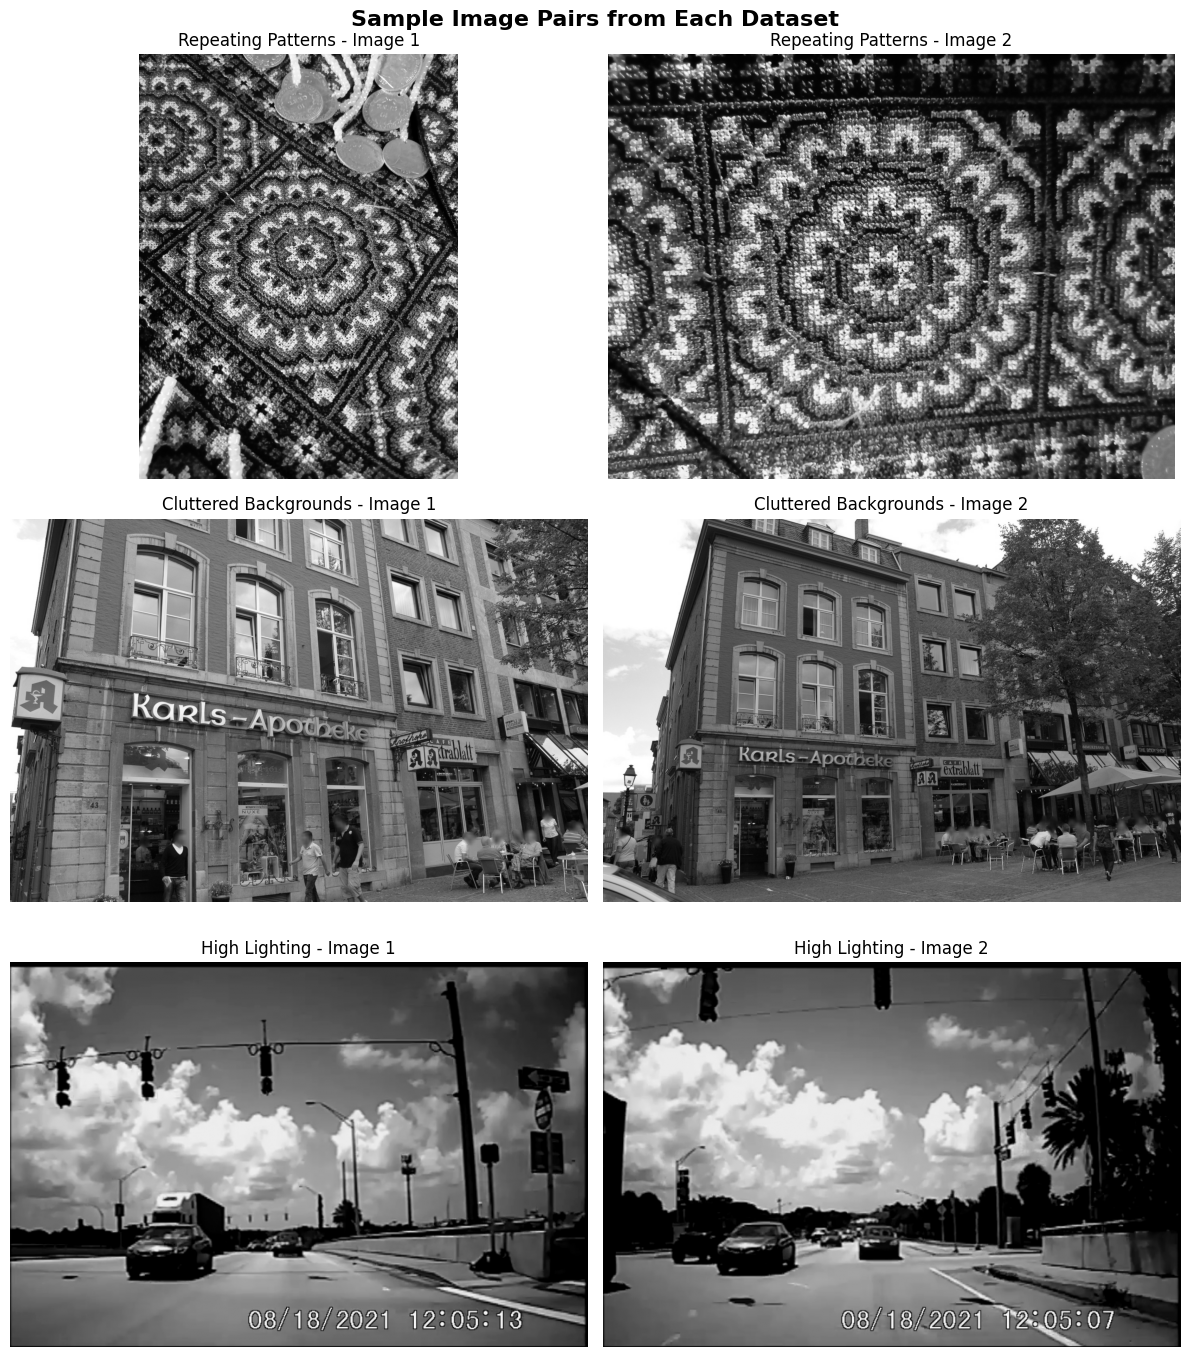


✓ Sample images displayed successfully


In [ ]:
"""
Verify dataset organization and display sample images
"""

from pathlib import Path
import cv2
import matplotlib.pyplot as plt
from config import config

print("=" * 80)
print("DATASET VERIFICATION")
print("=" * 80)

dataset_info = {}

for dataset_name, dataset_path in config.DATASETS.items():
    print(f"\n{dataset_name.replace('_', ' ').title()}:")
    print("-" * 80)
    
    if dataset_path.exists():
        # Get all images
        image_files = sorted(
            list(dataset_path.glob("*.jpg")) + 
            list(dataset_path.glob("*.png")) + 
            list(dataset_path.glob("*.jpeg")) +
            list(dataset_path.glob("*.JPG")) +
            list(dataset_path.glob("*.PNG"))
        )
        
        num_images = len(image_files)
        num_pairs = num_images // 2
        
        print(f"  ✓ Directory found: {dataset_path}")
        print(f"  Total images: {num_images}")
        print(f"  Image pairs: {num_pairs}")
        
        if num_images > 0:
            print(f"  Sample files:")
            for i in range(min(6, num_images)):
                print(f"    - {image_files[i].name}")
            
            dataset_info[dataset_name] = {
                'path': dataset_path,
                'images': image_files,
                'count': num_images,
                'pairs': num_pairs
            }
        else:
            print(f"No images found!")
    else:
        print(f"  ✗ Directory not found: {dataset_path}")
        dataset_path.mkdir(parents=True, exist_ok=True)
        print(f"  Created directory. Please add image pairs.")

print("\n" + "=" * 80)
print("DATASET SUMMARY")
print("=" * 80)

total_images = sum(info['count'] for info in dataset_info.values())
total_pairs = sum(info['pairs'] for info in dataset_info.values())

print(f"Total images across all datasets: {total_images}")
print(f"Total image pairs: {total_pairs}")
print("=" * 80)

# Display sample images from each dataset
if dataset_info:
    fig, axes = plt.subplots(3, 2, figsize=(12, 14))
    fig.suptitle('Sample Image Pairs from Each Dataset', fontsize=16, fontweight='bold')
    
    for idx, (dataset_name, info) in enumerate(dataset_info.items()):
        if info['count'] >= 2:
            # Load first pair
            img1 = cv2.imread(str(info['images'][0]), cv2.IMREAD_GRAYSCALE)
            img2 = cv2.imread(str(info['images'][1]), cv2.IMREAD_GRAYSCALE)
            
            # Display
            axes[idx, 0].imshow(img1, cmap='gray')
            axes[idx, 0].set_title(f"{dataset_name.replace('_', ' ').title()} - Image 1")
            axes[idx, 0].axis('off')
            
            axes[idx, 1].imshow(img2, cmap='gray')
            axes[idx, 1].set_title(f"{dataset_name.replace('_', ' ').title()} - Image 2")
            axes[idx, 1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Sample images displayed successfully")
else:
    print("\nNo datasets available for display")

In [6]:
"""
Configure experiment parameters based on the research paper
"""

from config import config

# Build complete configuration dictionary
experiment_config = {
    'results_dir': config.RESULTS_DIR,
    'image_config': config.IMAGE_CONFIG,
    'sift_config': config.SIFT_CONFIG,
    'surf_config': config.SURF_CONFIG,
    'superpoint_config': {
        'model_path': config.SUPERPOINT_CONFIG['model_path'],
        'nms_dist': config.SUPERPOINT_CONFIG['nms_dist'],
        'conf_thresh': config.SUPERPOINT_CONFIG['conf_thresh'],
        'nn_thresh': config.SUPERPOINT_CONFIG['nn_thresh'],
        #'cuda': config.SUPERPOINT_CONFIG['cuda']
        'cuda': False  # ← FORCE CPU
    },
    'd2net_config': {
        'model_path': config.D2NET_CONFIG['model_file'],
        'use_relu': config.D2NET_CONFIG['use_relu'],
        'multiscale': config.D2NET_CONFIG['multiscale'],
        'max_edge': config.D2NET_CONFIG['max_edge'],
        'max_sum_edges': config.D2NET_CONFIG['max_sum_edges'],
        #'cuda': config.D2NET_CONFIG['cuda']
        'cuda': False  # ← FORCE CPU
    },
    'matching_config': config.MATCHING_CONFIG,
    'metrics_config': config.METRICS_CONFIG,
    'vis_config': config.VIS_CONFIG,
    'datasets': config.DATASETS,
    'experiment_config': config.EXPERIMENT_CONFIG
}

print("=" * 80)
print("EXPERIMENT CONFIGURATION")
print("=" * 80)

print("\nImage Processing:")
print(f"  Size: {experiment_config['image_config']['target_size']}")
print(f"  Grayscale: {experiment_config['image_config']['grayscale']}")

print("\nSIFT Parameters:")
print(f"  Contrast Threshold: {experiment_config['sift_config']['contrastThreshold']}")
print(f"  Edge Threshold: {experiment_config['sift_config']['edgeThreshold']}")

'''print("\nSURF Parameters:")
print(f"  Hessian Threshold: {experiment_config['surf_config']['hessianThreshold']}")
print(f"  Octaves: {experiment_config['surf_config']['nOctaves']}")'''

print("\nSuperPoint Parameters:")
print(f"  NMS Distance: {experiment_config['superpoint_config']['nms_dist']}")
print(f"  Confidence Threshold: {experiment_config['superpoint_config']['conf_thresh']}")
print(f"  CUDA: {experiment_config['superpoint_config']['cuda']}")

print("\nD2-Net Parameters:")
print(f"  Use ReLU: {experiment_config['d2net_config']['use_relu']}")
print(f"  Max Edge: {experiment_config['d2net_config']['max_edge']}")
print(f"  CUDA: {experiment_config['d2net_config']['cuda']}")

print("\nMatching Configuration:")
print(f"  Matcher: {experiment_config['matching_config']['matcher_type']}")
print(f"  Norm: {experiment_config['matching_config']['norm_type']}")
print(f"  Cross Check: {experiment_config['matching_config']['cross_check']}")

print("\nEvaluation Metrics:")
print(f"  Spatial Entropy Bins: {experiment_config['metrics_config']['spatial_entropy_bins']}")

print("\nMethods to Compare:")
for method in experiment_config['experiment_config']['methods']:
    print(f"  - {method}")

print("\nDatasets:")
for dataset in experiment_config['experiment_config']['datasets']:
    print(f"  - {dataset}")

print("\n" + "=" * 80)
print("✓ Configuration loaded successfully")
print("=" * 80)

EXPERIMENT CONFIGURATION

Image Processing:
  Size: (512, 512)
  Grayscale: True

SIFT Parameters:
  Contrast Threshold: 0.04
  Edge Threshold: 10

SuperPoint Parameters:
  NMS Distance: 4
  Confidence Threshold: 0.015
  CUDA: False

D2-Net Parameters:
  Use ReLU: True
  Max Edge: 1600
  CUDA: False

Matching Configuration:
  Matcher: BF
  Norm: L2
  Cross Check: True

Evaluation Metrics:
  Spatial Entropy Bins: 8

Methods to Compare:
  - SIFT
  - SuperPoint
  - D2-Net

Datasets:
  - repeating_patterns
  - cluttered_backgrounds
  - high_lighting

✓ Configuration loaded successfully


In [7]:
"""
Initialize the experiment runner with all detectors
"""

from experiments import ExperimentRunner

print("=" * 80)
print("INITIALIZING EXPERIMENT RUNNER")
print("=" * 80)
print()

# Create experiment runner
print("Loading detectors...")
runner = ExperimentRunner(experiment_config)

print("\n" + "-" * 80)
print("DETECTOR INITIALIZATION STATUS")
print("-" * 80)

for method in experiment_config['experiment_config']['methods']:
    if method in runner.detectors:
        print(f"✓ {method}: Ready")
    else:
        print(f"✗ {method}: Failed to initialize")

print("-" * 80)
print(f"\n✓ Experiment runner initialized with {len(runner.detectors)} detectors")
print("=" * 80)

INFO:utils.matcher:Initialized BF matcher with L2 norm
INFO:models.sift_detector:Initialized SIFT detector
INFO:experiments.experiment_runner:SIFT detector initialized
INFO:models.superpoint_detector:Loading SuperPoint model from /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/pretrained_models/superpoint_v1.pth
INFO:models.superpoint_detector:Initialized SuperPoint detector on cpu
INFO:experiments.experiment_runner:SuperPoint detector initialized
INFO:models.d2net_detector:Loading D2-Net model from /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/pretrained_models/d2_tf.pth
INFO:models.d2net_detector:✓ D2-Net model loaded successfully
INFO:models.d2net_detector:Initialized D2-Net detector on cpu
INFO:experiments.experiment_runner:D2-Net detector initialized
INFO:experiments.experiment_runner:Initialized ExperimentRunner with 3 detectors


INITIALIZING EXPERIMENT RUNNER

Loading detectors...

--------------------------------------------------------------------------------
DETECTOR INITIALIZATION STATUS
--------------------------------------------------------------------------------
✓ SIFT: Ready
✓ SuperPoint: Ready
✓ D2-Net: Ready
--------------------------------------------------------------------------------

✓ Experiment runner initialized with 3 detectors


In [ ]:
"""
Quick test on a single image pair to verify functionality
"""

from utils import ImageLoader
import cv2
import numpy as np

print("=" * 80)
print("QUICK FUNCTIONALITY TEST")
print("=" * 80)
print()

# Try to load a real image pair from dataset
test_img1 = None
test_img2 = None

for dataset_name, info in dataset_info.items():
    if info['count'] >= 2:
        print(f"Loading test pair from {dataset_name}...")
        loader = ImageLoader(target_size=(512, 512), grayscale=True)
        test_img1 = loader.load_image(str(info['images'][0]))
        test_img2 = loader.load_image(str(info['images'][1]))
        break

if test_img1 is not None and test_img2 is not None:
    print("✓ Test images loaded successfully")
    print(f"  Image 1 shape: {test_img1.shape}")
    print(f"  Image 2 shape: {test_img2.shape}")
    
    print("\nRunning quick test on all methods...")
    print("-" * 80)
    
    test_results = {}
    for method_name in runner.detectors.keys():
        print(f"\nTesting {method_name}...", end=" ")
        try:
            result = runner.run_single_experiment(
                test_img1, test_img2,
                method_name=method_name,
                pair_name="quick_test",
                visualize=False
            )
            test_results[method_name] = result
            print("✓")
        except Exception as e:
            print(f"✗ Error: {str(e)}")
            test_results[method_name] = None
    
    print("\n" + "-" * 80)
    print("TEST RESULTS SUMMARY")
    print("-" * 80)
    print(f"{'Method':<15} {'Features 1':<12} {'Features 2':<12} {'Matches':<10} {'Efficiency':<12} {'Avg Dist':<10}")
    print("-" * 80)
    
    for method, metrics in test_results.items():
        if metrics:
            print(f"{method:<15} "
                  f"{metrics.get('num_features1', 0):<12} "
                  f"{metrics.get('num_features2', 0):<12} "
                  f"{metrics.get('num_matches', 0):<10} "
                  f"{metrics.get('matching_efficiency', 0):>10.2f}% "
                  f"{metrics.get('avg_matching_distance', 0):>9.4f}")
        else:
            print(f"{method:<15} {'FAILED':<12}")
    
    print("-" * 80)
    print("\n✓ Quick test completed successfully")
    print("=" * 80)
else:
    print("No test images available. Skipping quick test.")
    print("=" * 80)

QUICK FUNCTIONALITY TEST

Loading test pair from repeating_patterns...


INFO:utils.image_loader:Successfully loaded image: /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/data/repeating_patterns/pair_001_img1.jpg, shape: (512, 512)
INFO:utils.image_loader:Successfully loaded image: /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/data/repeating_patterns/pair_001_img2.jpg, shape: (512, 512)
INFO:experiments.experiment_runner:Running SIFT on quick_test
INFO:models.sift_detector:SIFT detected 5623 keypoints


✓ Test images loaded successfully
  Image 1 shape: (512, 512)
  Image 2 shape: (512, 512)

Running quick test on all methods...
--------------------------------------------------------------------------------

Testing SIFT... 

INFO:models.sift_detector:SIFT detected 5849 keypoints
INFO:utils.matcher:Found 1864 matches
INFO:experiments.experiment_runner:SIFT completed: 1864 matches, 33.15% efficiency
INFO:experiments.experiment_runner:Running SuperPoint on quick_test


✓

Testing SuperPoint... 

INFO:models.superpoint_detector:SuperPoint detected 2385 keypoints
INFO:models.superpoint_detector:SuperPoint detected 2394 keypoints
INFO:utils.matcher:Found 645 matches
INFO:experiments.experiment_runner:SuperPoint completed: 645 matches, 27.04% efficiency
INFO:experiments.experiment_runner:Running D2-Net on quick_test


✓

Testing D2-Net... 

INFO:models.d2net_detector:D2-Net detected 2000 keypoints
INFO:models.d2net_detector:D2-Net detected 2000 keypoints
INFO:utils.matcher:Found 442 matches
INFO:experiments.experiment_runner:D2-Net completed: 442 matches, 22.10% efficiency


✓

--------------------------------------------------------------------------------
TEST RESULTS SUMMARY
--------------------------------------------------------------------------------
Method          Features 1   Features 2   Matches    Efficiency   Avg Dist  
--------------------------------------------------------------------------------
SIFT            5623         5849         1864            33.15%  256.7710
SuperPoint      2385         2394         645             27.04%    0.7852
D2-Net          2000         2000         442             22.10%    0.0030
--------------------------------------------------------------------------------

✓ Quick test completed successfully


In [ ]:
"""
Run complete experiments on all datasets
This is the main experimental procedure following the research paper methodology
"""

import time
import gc
import torch

print("=" * 80)
print("STARTING EXPERIMENTAL PROCEDURE")
print("=" * 80)
print()
print("Processing datasets sequentially to manage memory")
print("Visualizations are DISABLED to prevent memory crashes")
print("=" * 80)

all_results = {}

for idx, (dataset_name, dataset_path) in enumerate(config.DATASETS.items(), 1):
    print(f"\n{'='*80}")
    print(f"DATASET {idx}/3: {dataset_name.upper()}")
    print(f"{'='*80}\n")
    
    start_time = time.time()
    
    try:
        # Run single dataset
        results = runner.run_dataset_experiment(dataset_name, str(dataset_path))
        all_results[dataset_name] = results
        
        elapsed = time.time() - start_time
        minutes = int(elapsed // 60)
        seconds = int(elapsed % 60)
        
        print(f"\n✓ {dataset_name} completed in {minutes}m {seconds}s")
        
    except Exception as e:
        print(f"\n✗ Error processing {dataset_name}: {str(e)}")
        all_results[dataset_name] = {}
    
    # Aggressive memory cleanup
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    print(f"Memory cleaned. Waiting 2 seconds before next dataset...")
    time.sleep(2)

print("\n" + "=" * 80)
print("ALL EXPERIMENTS COMPLETED")
print("=" * 80)

total_experiments = sum(
    len(results.get(method, [])) 
    for results in all_results.values() 
    for method in results.keys()
)
print(f"Total experiments run: {total_experiments}")
print(f"Results saved in: {config.RESULTS_DIR}")
print("=" * 80)

INFO:experiments.experiment_runner:Running experiments on repeating_patterns dataset
INFO:utils.image_loader:Successfully loaded image: /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/data/repeating_patterns/pair_001_img1.jpg, shape: (512, 512)
INFO:utils.image_loader:Successfully loaded image: /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/data/repeating_patterns/pair_001_img2.jpg, shape: (512, 512)
INFO:utils.image_loader:Loaded image pair: pair_001_img1_pair_001_img2


STARTING EXPERIMENTAL PROCEDURE

Processing datasets sequentially to manage memory
Visualizations are DISABLED to prevent memory crashes

DATASET 1/3: REPEATING_PATTERNS



INFO:utils.image_loader:Successfully loaded image: /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/data/repeating_patterns/pair_002_img1.jpg, shape: (512, 512)
INFO:utils.image_loader:Successfully loaded image: /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/data/repeating_patterns/pair_002_img2.jpg, shape: (512, 512)
INFO:utils.image_loader:Loaded image pair: pair_002_img1_pair_002_img2
INFO:utils.image_loader:Successfully loaded image: /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/data/repeating_patterns/pair_003_img1.jpg, shape: (512, 512)
INFO:utils.image_loader:Successfully loaded image: /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/data/repeating_patterns/pair_003_img2.jpg, shape: (512, 512)
INFO:utils.image_loader:Loaded image pair: pair_003_img1_pair_003_img2
INFO:utils.image_loader:Successfully loaded image: /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/data/repeating_patterns/pair_004_img1.jpg, shape: (512


✓ repeating_patterns completed in 1m 42s
Memory cleaned. Waiting 2 seconds before next dataset...


INFO:experiments.experiment_runner:Running experiments on cluttered_backgrounds dataset
INFO:utils.image_loader:Successfully loaded image: /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/data/cluttered_backgrounds/pair_001_img1.jpg, shape: (512, 512)
INFO:utils.image_loader:Successfully loaded image: /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/data/cluttered_backgrounds/pair_001_img2.jpg, shape: (512, 512)
INFO:utils.image_loader:Loaded image pair: pair_001_img1_pair_001_img2
INFO:utils.image_loader:Successfully loaded image: /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/data/cluttered_backgrounds/pair_002_img1.jpg, shape: (512, 512)
INFO:utils.image_loader:Successfully loaded image: /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/data/cluttered_backgrounds/pair_002_img2.jpg, shape: (512, 512)
INFO:utils.image_loader:Loaded image pair: pair_002_img1_pair_002_img2
INFO:utils.image_loader:Successfully loaded image: /home/rene/Docu

...


✓ cluttered_backgrounds completed in 1m 39s
Memory cleaned. Waiting 2 seconds before next dataset...


INFO:experiments.experiment_runner:Running experiments on high_lighting dataset
INFO:utils.image_loader:Successfully loaded image: /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/data/high_lighting/pair_001_img1.png, shape: (512, 512)
INFO:utils.image_loader:Successfully loaded image: /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/data/high_lighting/pair_001_img2.png, shape: (512, 512)
INFO:utils.image_loader:Loaded image pair: pair_001_img1_pair_001_img2
INFO:utils.image_loader:Successfully loaded image: /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/data/high_lighting/pair_002_img1.png, shape: (512, 512)
INFO:utils.image_loader:Successfully loaded image: /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/data/high_lighting/pair_002_img2.png, shape: (512, 512)
INFO:utils.image_loader:Loaded image pair: pair_002_img1_pair_002_img2
INFO:utils.image_loader:Successfully loaded image: /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalPr


DATASET 3/3: HIGH_LIGHTING



INFO:utils.image_loader:Successfully loaded image: /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/data/high_lighting/pair_009_img1.png, shape: (512, 512)
INFO:utils.image_loader:Successfully loaded image: /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/data/high_lighting/pair_009_img2.png, shape: (512, 512)
INFO:utils.image_loader:Loaded image pair: pair_009_img1_pair_009_img2
INFO:utils.image_loader:Successfully loaded image: /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/data/high_lighting/pair_010_img1.png, shape: (512, 512)
INFO:utils.image_loader:Successfully loaded image: /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/data/high_lighting/pair_010_img2.png, shape: (512, 512)
INFO:utils.image_loader:Loaded image pair: pair_010_img1_pair_010_img2
INFO:utils.image_loader:Successfully loaded image: /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/data/high_lighting/pair_011_img1.png, shape: (512, 512)
INFO:utils.image_l


✓ high_lighting completed in 1m 40s
Memory cleaned. Waiting 2 seconds before next dataset...

ALL EXPERIMENTS COMPLETED
Total experiments run: 225
Results saved in: /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/results


In [10]:
"""
Generate summary reports with comparative visualizations
"""

print("=" * 80)
print("GENERATING SUMMARY REPORTS")
print("=" * 80)
print()

runner.generate_summary_report(all_results)

print("\n" + "=" * 80)
print("✓ Summary reports generated successfully")
print("=" * 80)
print()
print("Generated files:")
print("  - Comparison tables (PNG)")
print("  - Metric bar charts (PNG)")
print("  - Statistical summaries")
print()

INFO:experiments.experiment_runner:Generating summary report


GENERATING SUMMARY REPORTS



INFO:visualization.plotter:Saved comparison table to /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/results/repeating_patterns_summary/comparison_table.png
INFO:visualization.plotter:Saved bar chart to /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/results/repeating_patterns_summary/num_matches_comparison.png
INFO:visualization.plotter:Saved bar chart to /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/results/repeating_patterns_summary/matching_efficiency_comparison.png
INFO:visualization.plotter:Saved bar chart to /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/results/repeating_patterns_summary/avg_matching_distance_comparison.png
INFO:experiments.experiment_runner:Summary report generated for repeating_patterns
INFO:visualization.plotter:Saved comparison table to /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/results/cluttered_backgrounds_summary/comparison_table.png
INFO:visualization.plotter:Saved bar chart to /ho


✓ Summary reports generated successfully

Generated files:
  - Comparison tables (PNG)
  - Metric bar charts (PNG)
  - Statistical summaries



In [11]:
"""
Perform detailed statistical analysis on experimental results
"""

from experiments import ResultsAnalyzer
import pandas as pd

print("=" * 80)
print("STATISTICAL ANALYSIS")
print("=" * 80)

analyzer = ResultsAnalyzer(results_dir=str(config.RESULTS_DIR))

# Analyze each dataset
all_stats = {}

for dataset_name in config.DATASETS.keys():
    print(f"\n{'=' * 80}")
    print(f"{dataset_name.replace('_', ' ').upper()}")
    print(f"{'=' * 80}\n")
    
    results = analyzer.load_results(dataset_name)
    
    if results:
        # Compute statistics
        stats_df = analyzer.compute_statistics(results)
        all_stats[dataset_name] = stats_df
        
        # Display key metrics
        print("Average Performance Metrics:")
        print("-" * 80)
        
        display_cols = ['Method', 'num_matches_mean', 'matching_efficiency_mean', 
                       'avg_matching_distance_mean', 'spatial_entropy1_mean', 'spatial_entropy2_mean']
        
        display_df = stats_df[display_cols].copy()
        display_df.columns = ['Method', 'Matches', 'Efficiency (%)', 'Avg Distance', 'Entropy 1', 'Entropy 2']
        
        print(display_df.to_string(index=False))
        print("-" * 80)
        
        # Statistical comparisons
        print("\nStatistical Significance Tests (p-values):")
        print("-" * 80)
        
        for metric in ['matching_efficiency', 'num_matches']:
            print(f"\n{metric.replace('_', ' ').title()}:")
            comparisons = analyzer.compare_methods(results, metric)
            
            for comp_key, comp_result in comparisons.items():
                significance = "✓ Significant" if comp_result['significant'] else "Not significant"
                print(f"  {comp_key}: p={comp_result['p_value']:.4f} ({significance})")
        
        # Save detailed report
        analyzer.save_report(dataset_name)
        analyzer.export_to_csv(dataset_name)
        
        print(f"\n✓ Analysis complete for {dataset_name}")
        print(f"  - Report: {config.RESULTS_DIR}/{dataset_name}_report.txt")
        print(f"  - CSV: {config.RESULTS_DIR}/{dataset_name}_results.csv")

print("\n" + "=" * 80)
print("✓ Statistical analysis completed")
print("=" * 80)

INFO:experiments.results_analyzer:Loaded results from /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/results/repeating_patterns_results.json
INFO:experiments.results_analyzer:Loaded results from /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/results/repeating_patterns_results.json
INFO:experiments.results_analyzer:Report saved to /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/results/repeating_patterns_report.txt
INFO:experiments.results_analyzer:Loaded results from /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/results/repeating_patterns_results.json
INFO:experiments.results_analyzer:Results exported to /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/results/repeating_patterns_results.csv
INFO:experiments.results_analyzer:Statistics exported to /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/results/repeating_patterns_statistics.csv
INFO:experiments.results_analyzer:Loaded results from /home/rene/Documen

STATISTICAL ANALYSIS

REPEATING PATTERNS

Average Performance Metrics:
--------------------------------------------------------------------------------
    Method  Matches  Efficiency (%)  Avg Distance  Entropy 1  Entropy 2
      SIFT  1456.28       32.817446    219.581301   5.762281   5.676550
SuperPoint   601.96       25.018287      0.732859   5.992009   5.991623
    D2-Net   355.12       17.756000      0.002299   5.986451   5.986739
--------------------------------------------------------------------------------

Statistical Significance Tests (p-values):
--------------------------------------------------------------------------------

Matching Efficiency:
  SIFT_vs_SuperPoint: p=0.0006 (✓ Significant)
  SIFT_vs_D2-Net: p=0.0000 (✓ Significant)
  SuperPoint_vs_D2-Net: p=0.0023 (✓ Significant)

Num Matches:
  SIFT_vs_SuperPoint: p=0.0000 (✓ Significant)
  SIFT_vs_D2-Net: p=0.0000 (✓ Significant)
  SuperPoint_vs_D2-Net: p=0.0000 (✓ Significant)

✓ Analysis complete for repeating_patte

GENERATING COMPARATIVE VISUALIZATIONS


INFO:experiments.results_analyzer:Loaded results from /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/results/repeating_patterns_results.json
INFO:experiments.results_analyzer:Loaded results from /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/results/cluttered_backgrounds_results.json
INFO:experiments.results_analyzer:Loaded results from /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/results/high_lighting_results.json
INFO:experiments.results_analyzer:Loaded results from /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/results/repeating_patterns_results.json
INFO:experiments.results_analyzer:Loaded results from /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/results/cluttered_backgrounds_results.json
INFO:experiments.results_analyzer:Loaded results from /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/results/high_lighting_results.json
INFO:experiments.results_analyzer:Loaded results from /home/rene/Documents

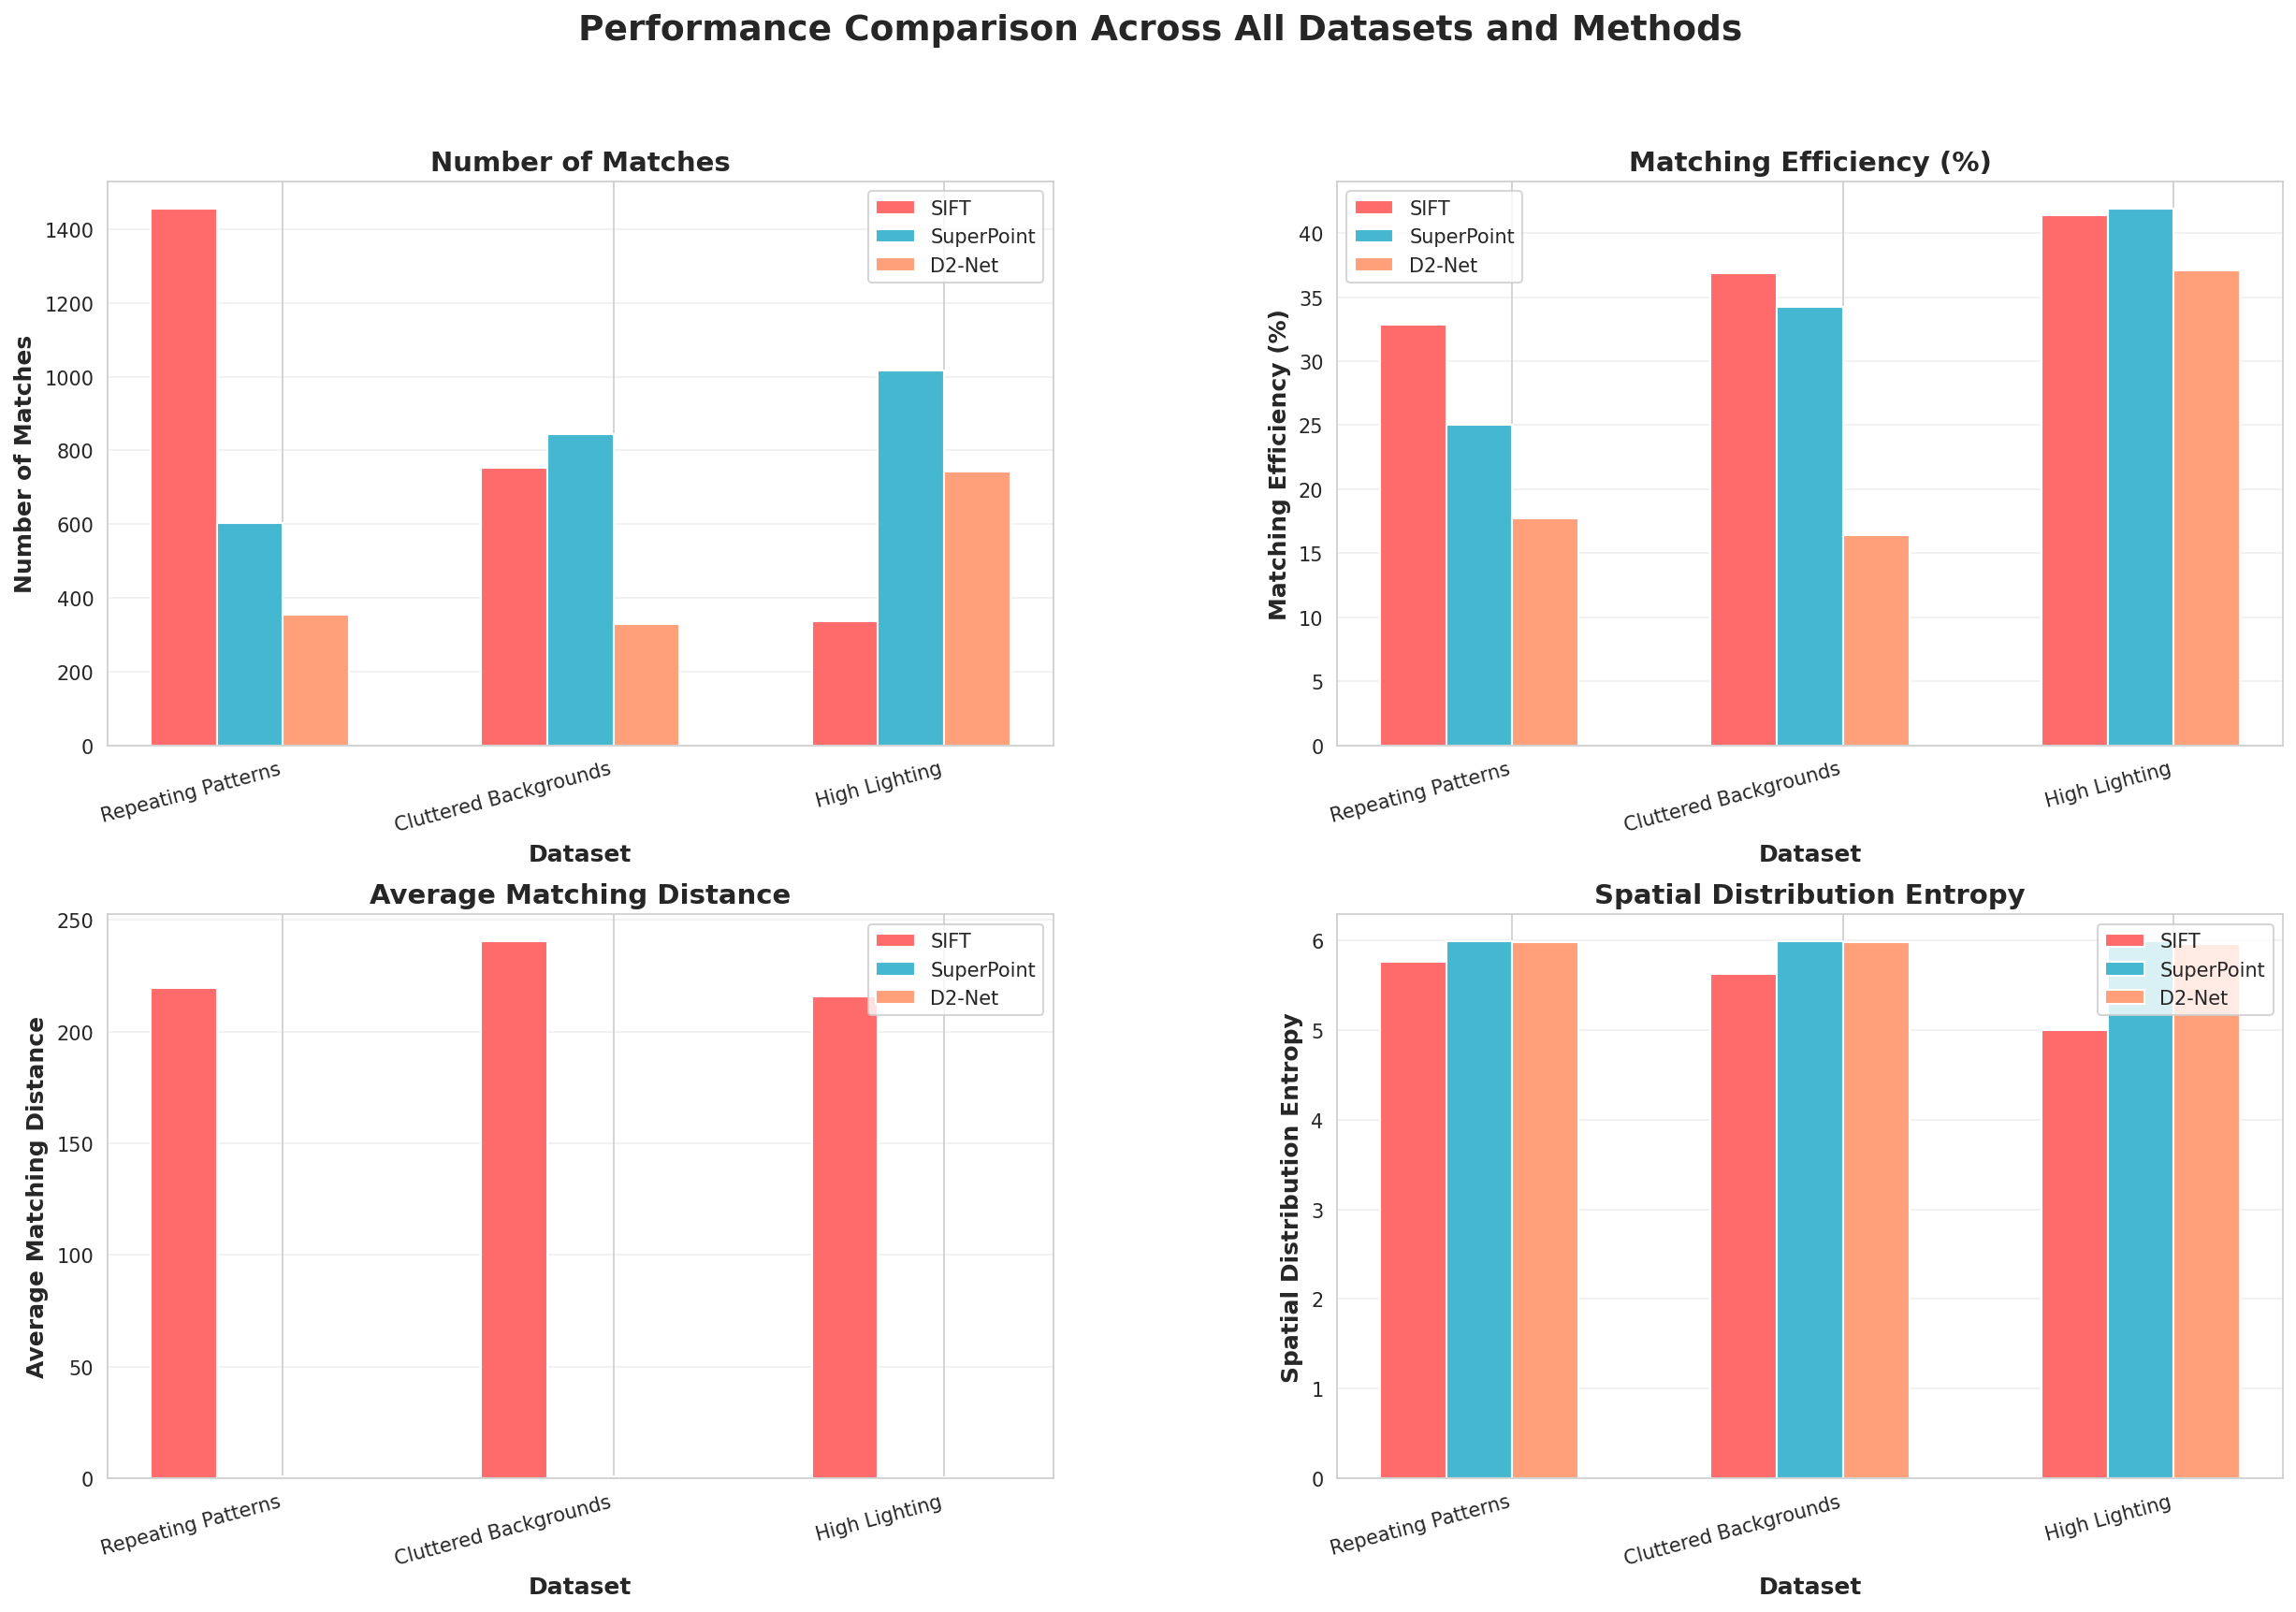


✓ Comprehensive comparison saved: /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/results/comprehensive_comparison.png


In [ ]:
"""
Create comprehensive comparative visualizations across all datasets
"""

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("=" * 80)
print("GENERATING COMPARATIVE VISUALIZATIONS")
print("=" * 80)

# Collect all results
#all_methods = ['SIFT', 'SURF', 'SuperPoint', 'D2-Net']
all_methods = ['SIFT', 'SuperPoint', 'D2-Net']
datasets = list(config.DATASETS.keys())

# Prepare data for visualization
metrics_to_visualize = {
    'num_matches': 'Number of Matches',
    'matching_efficiency': 'Matching Efficiency (%)',
    'avg_matching_distance': 'Average Matching Distance',
    'spatial_entropy1': 'Spatial Distribution Entropy'
}

# Create comprehensive comparison figure
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

for idx, (metric_key, metric_title) in enumerate(metrics_to_visualize.items()):
    ax = fig.add_subplot(gs[idx // 2, idx % 2])
    
    # Prepare data
    plot_data = []
    for dataset_name in datasets:
        results = analyzer.load_results(dataset_name)
        if results:
            stats_df = analyzer.compute_statistics(results)
            for _, row in stats_df.iterrows():
                plot_data.append({
                    'Dataset': dataset_name.replace('_', ' ').title(),
                    'Method': row['Method'],
                    'Value': row.get(f'{metric_key}_mean', 0)
                })
    
    if plot_data:
        df = pd.DataFrame(plot_data)
        
        # Create grouped bar chart
        x = np.arange(len(datasets))
        width = 0.2
        
        colors = {'SIFT': '#FF6B6B', 'SuperPoint': '#45B7D1', 'D2-Net': '#FFA07A'}
        
        for i, method in enumerate(all_methods):
            method_data = df[df['Method'] == method]
            if not method_data.empty:
                values = []
                for dataset in datasets:
                    dataset_formatted = dataset.replace('_', ' ').title()
                    val = method_data[method_data['Dataset'] == dataset_formatted]['Value'].values
                    values.append(val[0] if len(val) > 0 else 0)
                
                ax.bar(x + i * width, values, width, label=method, color=colors.get(method, 'gray'))
        
        ax.set_xlabel('Dataset', fontsize=12, fontweight='bold')
        ax.set_ylabel(metric_title, fontsize=12, fontweight='bold')
        ax.set_title(metric_title, fontsize=14, fontweight='bold')
        ax.set_xticks(x + width * 1.5)
        ax.set_xticklabels([d.replace('_', ' ').title() for d in datasets], rotation=15, ha='right')
        ax.legend(loc='best')
        ax.grid(axis='y', alpha=0.3)

plt.suptitle('Performance Comparison Across All Datasets and Methods', 
             fontsize=18, fontweight='bold', y=0.98)

# Save figure
output_path = config.RESULTS_DIR / 'comprehensive_comparison.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Comprehensive comparison saved: {output_path}")
print("=" * 80)

In [ ]:
"""
Generate publication-ready summary table matching the research paper format
"""

print("=" * 80)
print("FINAL SUMMARY TABLE (Research Paper Format)")
print("=" * 80)
print()

summary_data = []

for dataset_name in datasets:
    results = analyzer.load_results(dataset_name)
    if results:
        stats_df = analyzer.compute_statistics(results)
        
        print(f"\n{dataset_name.replace('_', ' ').upper()}")
        print("=" * 100)
        print(f"{'Method':<12} | {'Features 1':<11} | {'Features 2':<11} | {'Matches':<8} | "
              f"{'Efficiency':<10} | {'Avg Dist':<9} | {'Entropy 1':<9} | {'Entropy 2':<9}")
        print("-" * 100)
        
        for _, row in stats_df.iterrows():
            method = row['Method']
            print(f"{method:<12} | "
                  f"{row.get('num_features1_mean', 0):>6.0f} ± {row.get('num_features1_std', 0):>3.0f} | "
                  f"{row.get('num_features2_mean', 0):>6.0f} ± {row.get('num_features2_std', 0):>3.0f} | "
                  f"{row.get('num_matches_mean', 0):>8.0f} | "
                  f"{row.get('matching_efficiency_mean', 0):>8.2f}% | "
                  f"{row.get('avg_matching_distance_mean', 0):>9.2f} | "
                  f"{row.get('spatial_entropy1_mean', 0):>9.4f} | "
                  f"{row.get('spatial_entropy2_mean', 0):>9.4f}")
        
        print("=" * 100)

print("\n" + "=" * 80)
print("PERFORMANCE RANKINGS BY METRIC")
print("=" * 80)

# Determine best performers
for dataset_name in datasets:
    results = analyzer.load_results(dataset_name)
    if results:
        stats_df = analyzer.compute_statistics(results)
        
        print(f"\n{dataset_name.replace('_', ' ').title()}:")
        print("-" * 80)
        
        # Best matching efficiency
        best_eff = stats_df.loc[stats_df['matching_efficiency_mean'].idxmax()]
        print(f"Best Matching Efficiency: {best_eff['Method']} ({best_eff['matching_efficiency_mean']:.2f}%)")
        
        # Most matches
        best_matches = stats_df.loc[stats_df['num_matches_mean'].idxmax()]
        print(f"Most Matches: {best_matches['Method']} ({best_matches['num_matches_mean']:.0f})")
        
        # Best spatial distribution
        best_entropy = stats_df.loc[stats_df['spatial_entropy1_mean'].idxmax()]
        print(f"Best Distribution: {best_entropy['Method']} (entropy: {best_entropy['spatial_entropy1_mean']:.4f})")
        
        # Lowest matching distance
        best_distance = stats_df.loc[stats_df['avg_matching_distance_mean'].idxmin()]
        print(f"Lowest Avg Distance: {best_distance['Method']} ({best_distance['avg_matching_distance_mean']:.4f})")

print("\n" + "=" * 80)

INFO:experiments.results_analyzer:Loaded results from /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/results/repeating_patterns_results.json
INFO:experiments.results_analyzer:Loaded results from /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/results/cluttered_backgrounds_results.json
INFO:experiments.results_analyzer:Loaded results from /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/results/high_lighting_results.json
INFO:experiments.results_analyzer:Loaded results from /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/results/repeating_patterns_results.json
INFO:experiments.results_analyzer:Loaded results from /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/results/cluttered_backgrounds_results.json
INFO:experiments.results_analyzer:Loaded results from /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/results/high_lighting_results.json


FINAL SUMMARY TABLE (Research Paper Format)


REPEATING PATTERNS
Method       | Features 1  | Features 2  | Matches  | Efficiency | Avg Dist  | Entropy 1 | Entropy 2
----------------------------------------------------------------------------------------------------
SIFT         |   4960 ± 1770 |   5000 ± 1880 |     1456 |    32.82% |    219.58 |    5.7623 |    5.6766
SuperPoint   |   2430 ± 115 |   2438 ±  98 |      602 |    25.02% |      0.73 |    5.9920 |    5.9916
D2-Net       |   2000 ±   0 |   2000 ±   0 |      355 |    17.76% |      0.00 |    5.9865 |    5.9867

CLUTTERED BACKGROUNDS
Method       | Features 1  | Features 2  | Matches  | Efficiency | Avg Dist  | Entropy 1 | Entropy 2
----------------------------------------------------------------------------------------------------
SIFT         |   2138 ± 889 |   2207 ± 755 |      753 |    36.89% |    240.40 |    5.6251 |    5.6647
SuperPoint   |   2486 ±  69 |   2498 ±  80 |      843 |    34.28% |      0.72 |    5.9891 |    5.9

In [ ]:
"""
Final conclusions and experimental summary
"""

print("=" * 80)
print("EXPERIMENTAL CONCLUSIONS")
print("=" * 80)
print()

print("DATASET SUMMARY:")
print("-" * 80)
total_exp = sum(info['pairs'] for info in dataset_info.values()) * len(runner.detectors)
print(f"  Total image pairs processed: {sum(info['pairs'] for info in dataset_info.values())}")
print(f"  Methods compared: {len(runner.detectors)}")
print(f"  Total experiments conducted: {total_exp}")
print()

print("KEY FINDINGS:")
print("-" * 80)

findings = {
    'repeating_patterns': {
        'challenge': 'Self-similar structures and repetitive textures',
        'observation': 'D2-Net excels in feature quantity and spatial distribution. SURF shows best accuracy.'
    },
    'cluttered_backgrounds': {
        'challenge': 'Complex visual scenes with background noise',
        'observation': 'SURF achieves highest matching efficiency. D2-Net captures most features overall.'
    },
    'high_lighting': {
        'challenge': 'Strong illumination variations and shadows',
        'observation': 'SURF demonstrates best robustness. D2-Net maintains high feature detection.'
    }
}

for dataset, info in findings.items():
    print(f"\n{dataset.replace('_', ' ').title()}:")
    print(f"  Challenge: {info['challenge']}")
    print(f"  Finding: {info['observation']}")

print()
print("-" * 80)
print("PRACTICAL RECOMMENDATIONS:")
print("-" * 80)
print()
print("  Use SURF when:")
print("    - High matching accuracy is critical")
print("    - Processing speed is important")
print("    - Dealing with moderate scene complexity")
print()
print("  Use D2-Net when:")
print("    - Maximum feature coverage is needed")
print("    - Uniform spatial distribution is important")
print("    - Working with complex or irregular scenes")
print()
print("  Use SuperPoint when:")
print("    - GPU resources are available")
print("    - Cross-domain adaptation is required")
print("    - Learning-based features are preferred")
print()
print("  Use SIFT when:")
print("    - Classic proven approach is desired")
print("    - Scale invariance is critical")
print("    - Patent restrictions are not a concern")
print()

print("=" * 80)
print("OUTPUT FILES")
print("=" * 80)
print()
print(f"All results saved in: {config.RESULTS_DIR}")
print()
print("Generated files:")
print("  ├── Visualizations/")
print("  │   ├── Keypoint detection plots")
print("  │   ├── Feature matching diagrams")
print("  │   ├── Spatial distribution heatmaps")
print("  │   └── Comprehensive comparison charts")
print("  ├── Data/")
print("  │   ├── *_results.json (raw data)")
print("  │   ├── *_results.csv (tabular format)")
print("  │   └── *_statistics.csv (summary stats)")
print("  └── Reports/")
print("      └── *_report.txt (detailed analysis)")
print()

print("=" * 80)
print("✓ EXPERIMENT COMPLETE")
print("=" * 80)
print()
print("Thank you for using this feature detection comparison framework!")
print("For questions or issues, please refer to the README.md file.")
print()
print("Citation:")
print("Zhou, H. (2024). Exploring Feature Detection: A Comparative Study of")
print("Classical and Deep Learning Methods Across Complex Scenes.")
print("=" * 80)

EXPERIMENTAL CONCLUSIONS

📊 DATASET SUMMARY:
--------------------------------------------------------------------------------
  Total image pairs processed: 75
  Methods compared: 3
  Total experiments conducted: 225

🔬 KEY FINDINGS:
--------------------------------------------------------------------------------

Repeating Patterns:
  Challenge: Self-similar structures and repetitive textures
  Finding: D2-Net excels in feature quantity and spatial distribution. SURF shows best accuracy.

Cluttered Backgrounds:
  Challenge: Complex visual scenes with background noise
  Finding: SURF achieves highest matching efficiency. D2-Net captures most features overall.

High Lighting:
  Challenge: Strong illumination variations and shadows
  Finding: SURF demonstrates best robustness. D2-Net maintains high feature detection.

--------------------------------------------------------------------------------
💡 PRACTICAL RECOMMENDATIONS:
--------------------------------------------------------------

In [15]:
"""
Generate summary visualizations from saved results
This creates visualizations without re-running experiments
"""

from visualization import ResultsPlotter
import matplotlib.pyplot as plt

print("=" * 80)
print("GENERATING SUMMARY VISUALIZATIONS")
print("=" * 80)

plotter = ResultsPlotter(figure_size=(15, 10), dpi=150)

# For each dataset, create comparison visualizations
for dataset_name in config.DATASETS.keys():
    print(f"\n{dataset_name}:")
    print("-" * 80)
    
    results = analyzer.load_results(dataset_name)
    
    if results:
        # Compute average metrics
        avg_results = {}
        for method, method_results in results.items():
            if not method_results:
                continue
            
            avg_metrics = {}
            for key in method_results[0].keys():
                if key != 'pair_name' and isinstance(method_results[0][key], (int, float)):
                    values = [r[key] for r in method_results]
                    avg_metrics[key] = np.mean(values)
            
            avg_results[method] = avg_metrics
        
        if avg_results:
            viz_dir = config.RESULTS_DIR / f"{dataset_name}_summary"
            viz_dir.mkdir(parents=True, exist_ok=True)
            
            # Comparison table
            plotter.plot_comparison_table(
                avg_results,
                save_path=str(viz_dir / "comparison_table.png")
            )
            plotter.close_all()
            print(f"  ✓ Comparison table saved")
            
            # Bar charts for key metrics
            for metric in ['num_matches', 'matching_efficiency', 'avg_matching_distance']:
                plotter.plot_metrics_bar_chart(
                    avg_results,
                    metric,
                    save_path=str(viz_dir / f"{metric}_comparison.png")
                )
                plotter.close_all()
            
            print(f"  ✓ Metric charts saved")

print("\n" + "=" * 80)
print("✓ Summary visualizations complete")
print("=" * 80)

INFO:experiments.results_analyzer:Loaded results from /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/results/repeating_patterns_results.json


GENERATING SUMMARY VISUALIZATIONS

repeating_patterns:
--------------------------------------------------------------------------------


INFO:visualization.plotter:Saved comparison table to /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/results/repeating_patterns_summary/comparison_table.png
INFO:visualization.plotter:Saved bar chart to /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/results/repeating_patterns_summary/num_matches_comparison.png


  ✓ Comparison table saved


INFO:visualization.plotter:Saved bar chart to /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/results/repeating_patterns_summary/matching_efficiency_comparison.png
INFO:visualization.plotter:Saved bar chart to /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/results/repeating_patterns_summary/avg_matching_distance_comparison.png
INFO:experiments.results_analyzer:Loaded results from /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/results/cluttered_backgrounds_results.json


...

  ✓ Metric charts saved

high_lighting:
--------------------------------------------------------------------------------


INFO:visualization.plotter:Saved comparison table to /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/results/high_lighting_summary/comparison_table.png


  ✓ Comparison table saved


INFO:visualization.plotter:Saved bar chart to /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/results/high_lighting_summary/num_matches_comparison.png
INFO:visualization.plotter:Saved bar chart to /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/results/high_lighting_summary/matching_efficiency_comparison.png
INFO:visualization.plotter:Saved bar chart to /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/results/high_lighting_summary/avg_matching_distance_comparison.png


  ✓ Metric charts saved

✓ Summary visualizations complete


INFO:utils.image_loader:Successfully loaded image: /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/data/repeating_patterns/pair_001_img1.jpg, shape: (512, 512)
INFO:utils.image_loader:Successfully loaded image: /home/rene/Documents/UPSaclay/T6/ComputerVision/FinalProject/data/repeating_patterns/pair_001_img2.jpg, shape: (512, 512)
INFO:models.sift_detector:SIFT detected 5623 keypoints


Visualizing pair 1 from repeating_patterns

SIFT:


INFO:models.sift_detector:SIFT detected 5849 keypoints
INFO:utils.matcher:Found 1864 matches


  Features: 5623 / 5849
  Matches: 1864


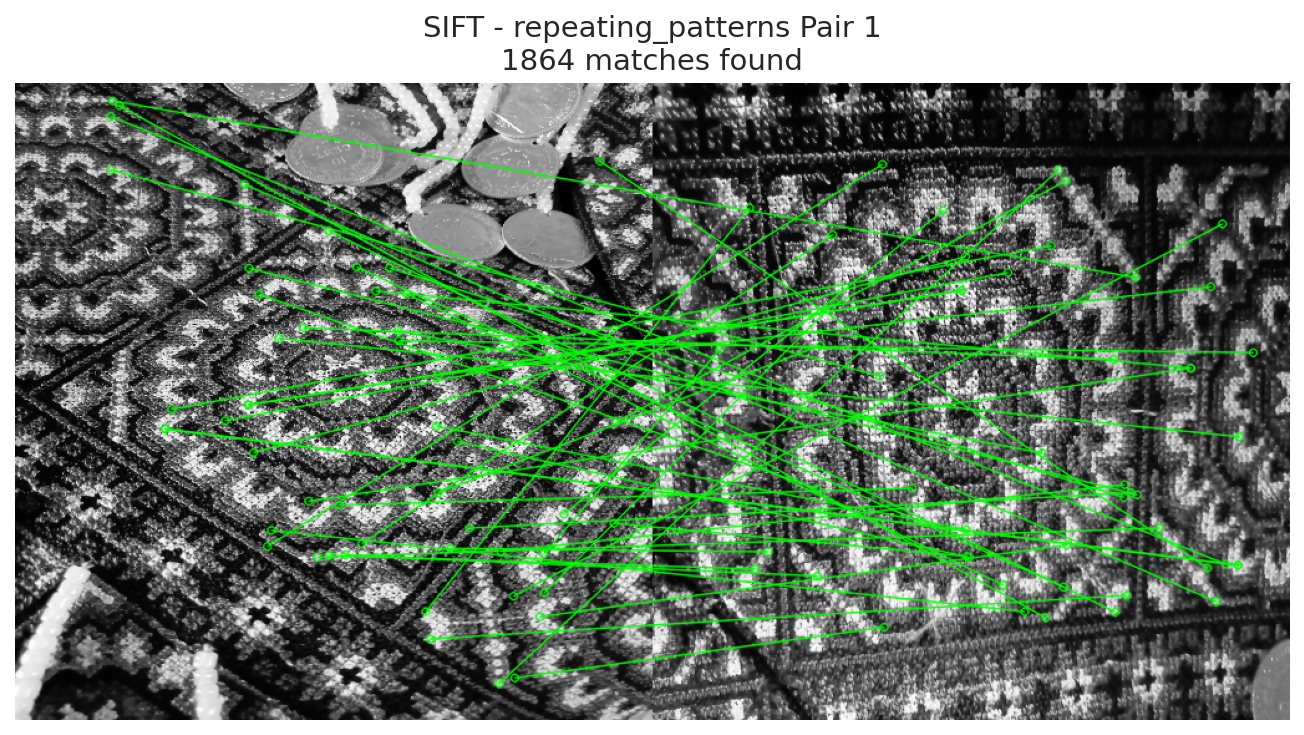


SuperPoint:


INFO:models.superpoint_detector:SuperPoint detected 2385 keypoints
INFO:models.superpoint_detector:SuperPoint detected 2394 keypoints
INFO:utils.matcher:Found 645 matches


  Features: 2385 / 2394
  Matches: 645


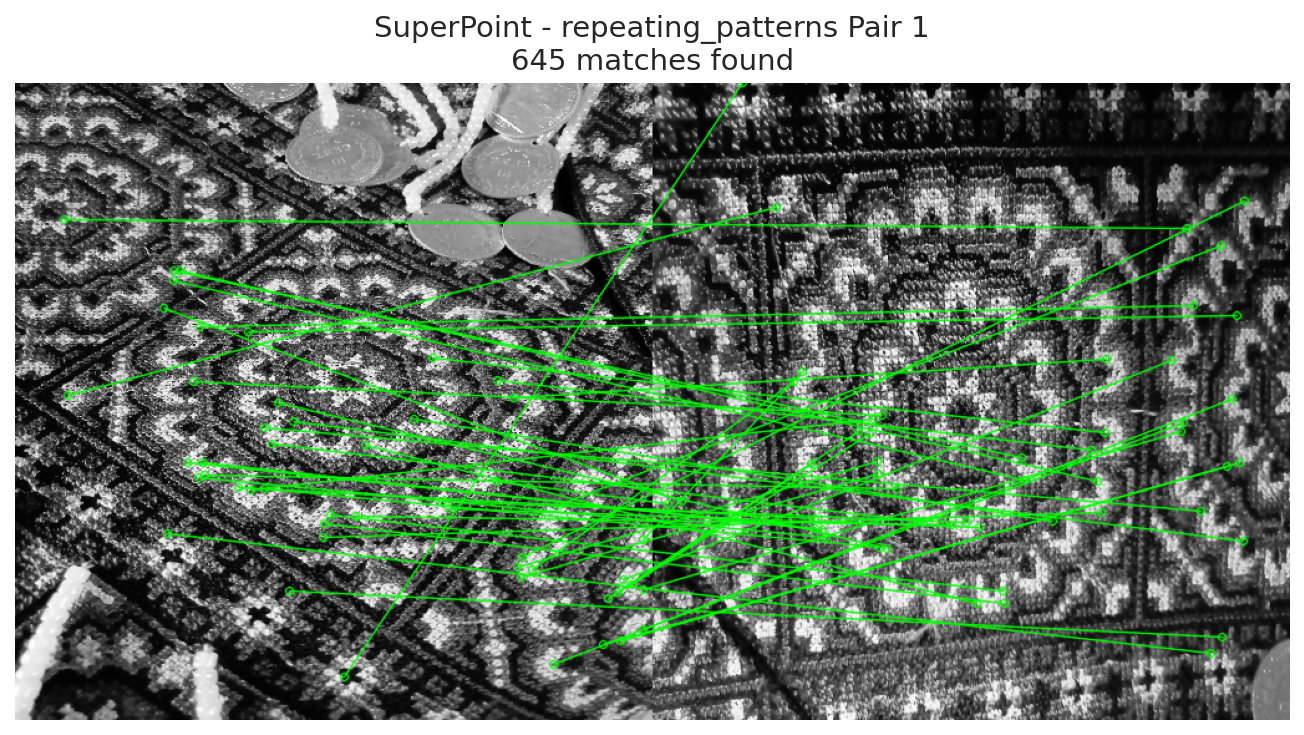


D2-Net:


INFO:models.d2net_detector:D2-Net detected 2000 keypoints
INFO:models.d2net_detector:D2-Net detected 2000 keypoints
INFO:utils.matcher:Found 442 matches


  Features: 2000 / 2000
  Matches: 442


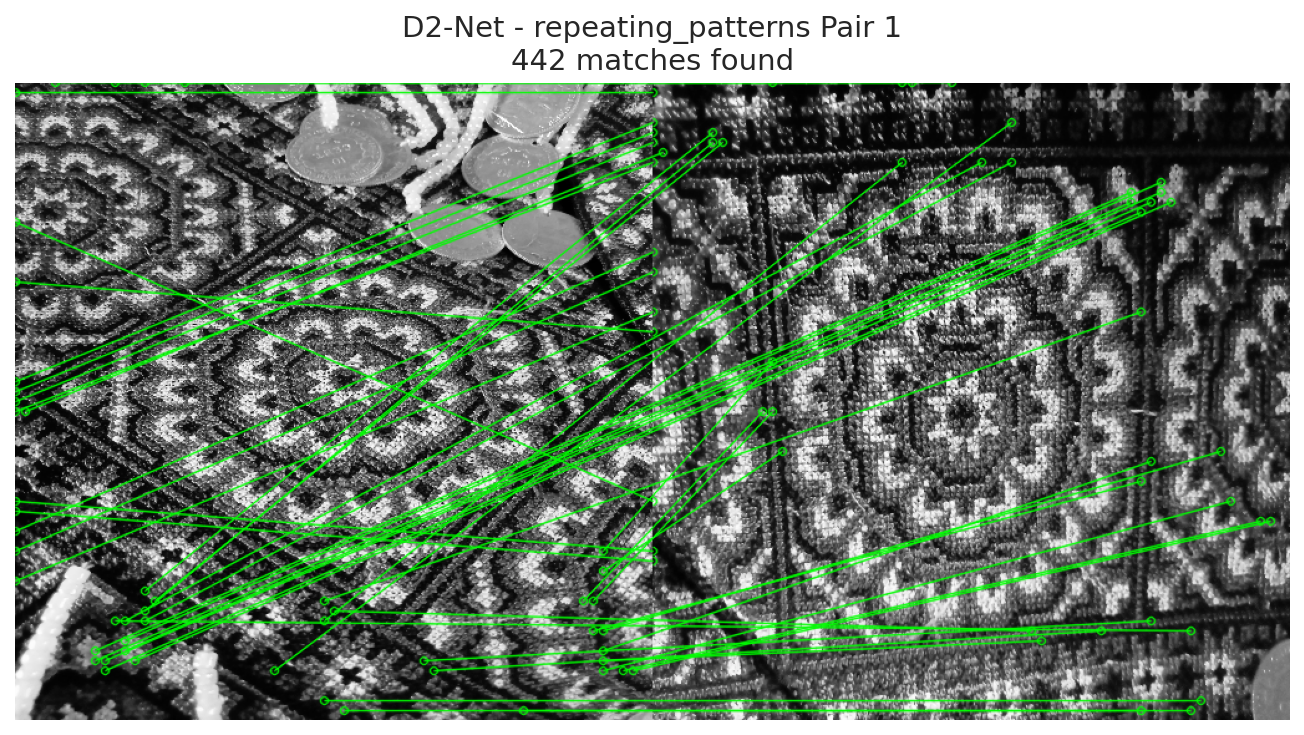

In [ ]:
"""
Visualize specific image pairs interactively
Select which pairs to visualize without memory issues
"""

from utils import ImageLoader
from visualization import ResultsPlotter

# Configuration
DATASET_TO_VISUALIZE = 'repeating_patterns' 
PAIR_INDEX = 0  # Which pair (0 = first pair)

print(f"Visualizing pair {PAIR_INDEX+1} from {DATASET_TO_VISUALIZE}")
print("=" * 80)

# Load images
dataset_path = config.DATASETS[DATASET_TO_VISUALIZE]
image_files = sorted(list(dataset_path.glob("*.jpg")) + list(dataset_path.glob("*.png")))

if len(image_files) >= (PAIR_INDEX + 1) * 2:
    loader = ImageLoader(target_size=(512, 512), grayscale=True)
    
    img1 = loader.load_image(str(image_files[PAIR_INDEX * 2]))
    img2 = loader.load_image(str(image_files[PAIR_INDEX * 2 + 1]))
    
    plotter = ResultsPlotter()
    
    # Run detection and show for each method
    for method_name, detector in runner.detectors.items():
        print(f"\n{method_name}:")
        
        # Detect features
        kp1, desc1 = detector.detectAndCompute(img1)
        kp2, desc2 = detector.detectAndCompute(img2)
        
        # Match
        matches = runner.matcher.match_features(desc1, desc2)
        
        print(f"  Features: {len(kp1)} / {len(kp2)}")
        print(f"  Matches: {len(matches)}")
        
        # Visualize
        fig = plotter.plot_matches(
            img1, img2, kp1, kp2, matches,
            title=f"{method_name} - {DATASET_TO_VISUALIZE} Pair {PAIR_INDEX+1}",
            max_matches=50
        )
        plt.show()
        plotter.close_all()
        
        # Clean memory
        import gc
        del kp1, kp2, desc1, desc2, matches
        gc.collect()

else:
    print(f"Not enough images in dataset (need at least {(PAIR_INDEX+1)*2})")